# **COSC-5806-W03 - Data Analysis With Python**
# Group: Prashansa Rathod, Vansh Vansh
# Multivariate Time-Series Health Index and Early Anomaly Detection Framework for Wind Turbine Predictive Maintenance Using SCADA Data

# **Load the dataset**

In [108]:
import pandas as pd

# load dataset
df = pd.read_csv("VestasV52_10_min_raw_SCADA_DkIT 30_Jan2006-12_Mar2020.csv")

# view first rows
df.head()


,Timestamps,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,...,RotorRPM,EnvirTemp,NacelTemp,GearOilTemp,GearBearTemp,GenTemp,GenPh1Temp,GenPh2Temp,GenPh3Temp,GenBearTemp
0,2006-01-30 20:30,9.5,0.7,101.9,2.0,527.3,633.2,362.3,48.8,0.0,...,26.1,5,18,55,63,999,82,82,81,62
1,2006-01-30 20:40,9.9,0.9,107.1,2.5,584.5,731.5,353.3,74.6,0.0,...,26.1,5,18,57,65,999,86,85,85,64
2,2006-01-30 20:50,9.3,0.9,105.0,-0.5,527.3,728.1,291.1,92.7,0.0,...,25.9,4,17,57,65,999,89,88,88,64
3,2006-01-30 21:00,8.7,0.8,106.3,0.8,428.0,669.4,216.7,92.9,0.0,...,25.5,4,15,55,63,999,88,88,88,60
4,2006-01-30 21:10,8.6,0.8,103.5,-2.0,434.7,622.2,233.1,80.3,0.0,...,25.4,4,15,57,66,999,85,85,84,57


# **Exploratory data Analysis**

In [109]:
df.columns

Index(['Timestamps', 'WindSpeed', 'StdDevWindSpeed', 'WindDirAbs',
       'WindDirRel', 'Power', 'MaxPower', 'MinPower', 'StdDevPower', 'AvgRPow',
       'Pitch', 'GenRPM', 'RotorRPM', 'EnvirTemp', 'NacelTemp', 'GearOilTemp',
       'GearBearTemp', 'GenTemp', 'GenPh1Temp', 'GenPh2Temp', 'GenPh3Temp',
       'GenBearTemp'],
      dtype='object')

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653103 entries, 0 to 653102
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamps       653103 non-null  object 
 1   WindSpeed        653103 non-null  float64
 2   StdDevWindSpeed  653103 non-null  float64
 3   WindDirAbs       653103 non-null  float64
 4   WindDirRel       653103 non-null  float64
 5   Power            653103 non-null  float64
 6   MaxPower         653103 non-null  float64
 7   MinPower         653103 non-null  float64
 8   StdDevPower      653103 non-null  float64
 9   AvgRPow          653103 non-null  float64
 10  Pitch            653103 non-null  float64
 11  GenRPM           653103 non-null  int64  
 12  RotorRPM         653103 non-null  float64
 13  EnvirTemp        653103 non-null  int64  
 14  NacelTemp        653103 non-null  int64  
 15  GearOilTemp      653103 non-null  int64  
 16  GearBearTemp     653103 non-null  int6

Check missing values

In [111]:
df['Timestamps'] = pd.to_datetime(df['Timestamps'], format='mixed')

In [112]:
import numpy as np

df.replace(999, np.nan, inplace=True)

In [113]:
df = df.dropna(subset=['WindSpeed','Power','RotorRPM'])

In [114]:
df = df[(df['Power'] > 0) & (df['WindSpeed'] > 0)]

In [115]:
df = df[df['WindSpeed'] < 30]

In [116]:
df.interpolate(inplace=True)

In [117]:
df = df.sort_values('Timestamps')
df.set_index('Timestamps', inplace=True)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456813 entries, 2006-01-30 20:30:00 to 2020-03-12 12:20:00
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   WindSpeed        456813 non-null  float64
 1   StdDevWindSpeed  456813 non-null  float64
 2   WindDirAbs       456813 non-null  float64
 3   WindDirRel       456813 non-null  float64
 4   Power            456813 non-null  float64
 5   MaxPower         456813 non-null  float64
 6   MinPower         456813 non-null  float64
 7   StdDevPower      456813 non-null  float64
 8   AvgRPow          456813 non-null  float64
 9   Pitch            456813 non-null  float64
 10  GenRPM           456813 non-null  float64
 11  RotorRPM         456813 non-null  float64
 12  EnvirTemp        456813 non-null  int64  
 13  NacelTemp        456813 non-null  int64  
 14  GearOilTemp      456813 non-null  int64  
 15  GearBearTemp     456813 non-null  int64  
 16  GenT

In [119]:
df = df.drop(columns=['GenTemp'])

- Visualization

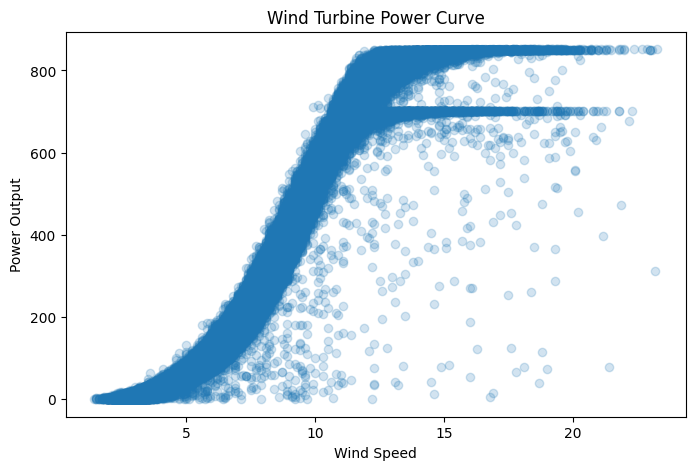

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['WindSpeed'], df['Power'], alpha=0.2)
plt.xlabel("Wind Speed")
plt.ylabel("Power Output")
plt.title("Wind Turbine Power Curve")
plt.show()

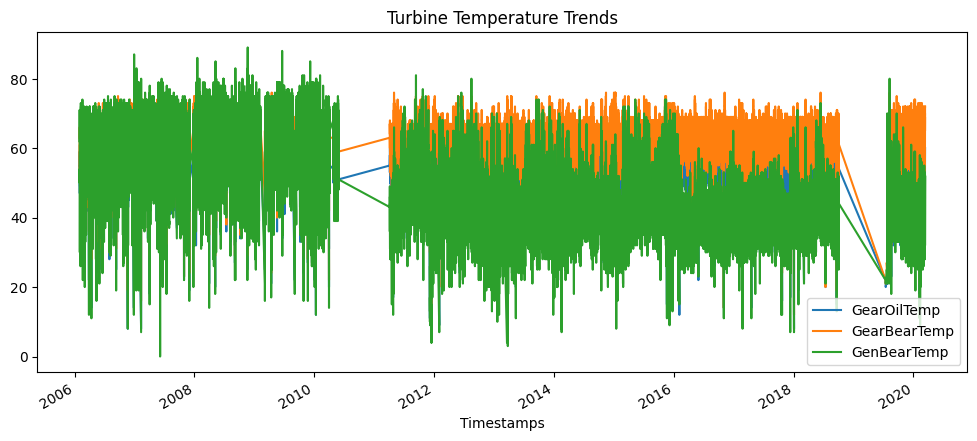

In [121]:
df[['GearOilTemp','GearBearTemp','GenBearTemp']].plot(figsize=(12,5))
plt.title("Turbine Temperature Trends")
plt.show()

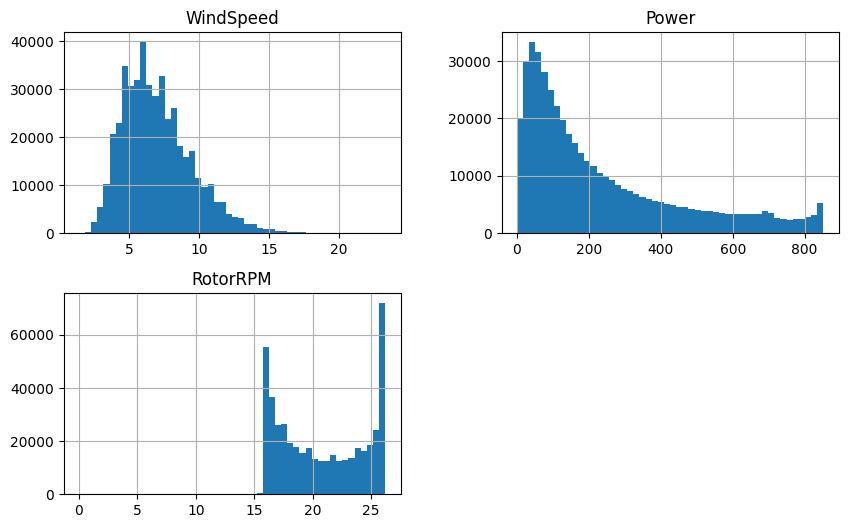

In [122]:
df[['WindSpeed','Power','RotorRPM']].hist(figsize=(10,6), bins=50)
plt.show()

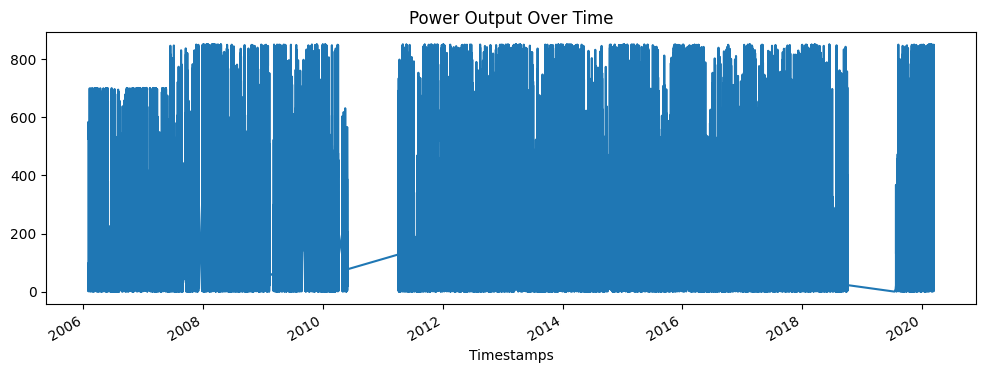

In [123]:
df['Power'].plot(figsize=(12,4))
plt.title("Power Output Over Time")
plt.show()

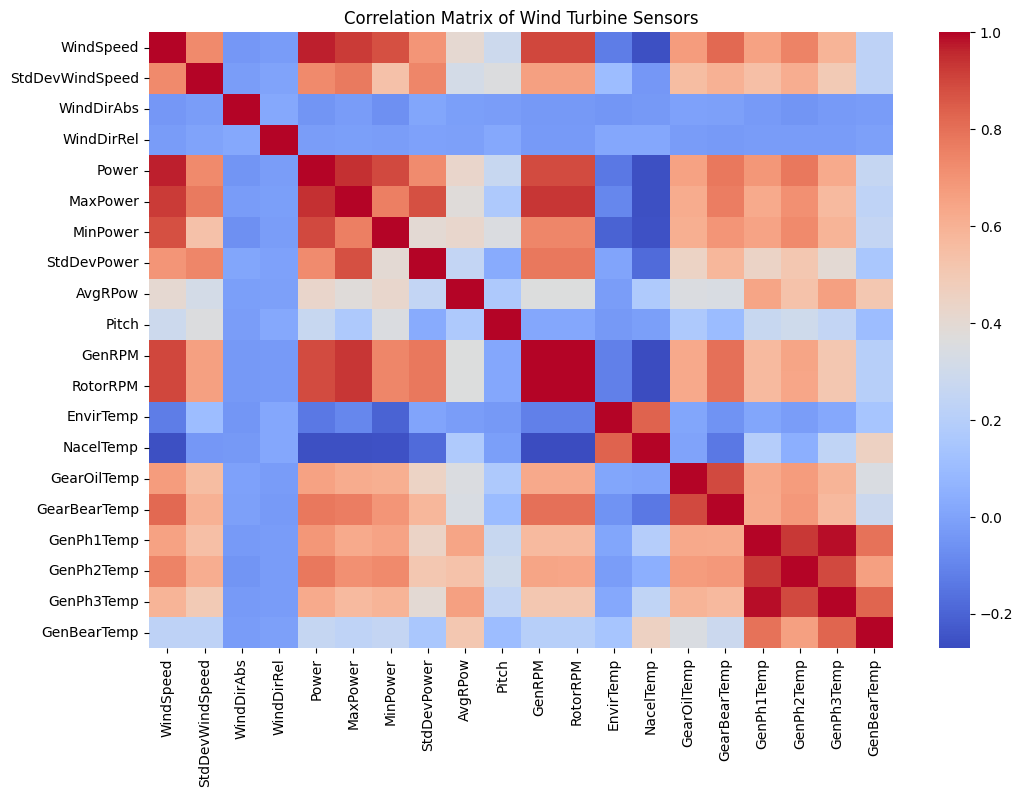

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Wind Turbine Sensors")
plt.show()

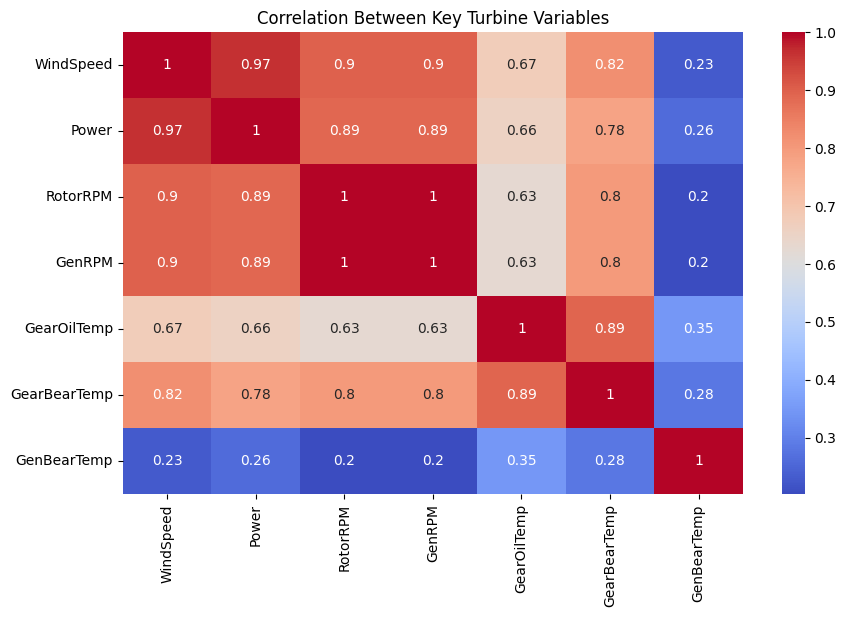

In [125]:
cols = [
    'WindSpeed','Power','RotorRPM','GenRPM',
    'GearOilTemp','GearBearTemp','GenBearTemp'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Between Key Turbine Variables")
plt.show()

---
WindSpeed → Power

Correlation ≈ 0.72

This means:

As wind speed increases, power output increases.

This confirms normal turbine behavior.

---

RotorRPM ↔ GenRPM

Correlation ≈ 1.0

This is expected because:

Generator RPM is derived from rotor speed through the gearbox.

---

RotorRPM → Temperature

Correlation ≈ 0.81–0.86

Meaning: Higher rotational speed → higher mechanical load → higher temperature.

---

GearOilTemp ↔ GearBearTemp

Correlation ≈ 0.99

This means gearbox oil and bearing temperatures behave almost identically.

This confirms thermal coupling in the gearbox system.

---

Generator Bearing Temperature

Correlation ≈ 0.72–0.73 with gearbox temps

Meaning: Heat from drivetrain spreads across the turbine components.

---


# **Conclusion of EDA**:
Significant correlation was observed between wind speed and power output, as well as between drivetrain rotational speeds and component temperatures. The gearbox oil temperature and bearing temperature have an extremely high correlation, implying thermal coupling within the drivetrain system. These correlation results validate the expected operation of the wind turbine and also provide insight into the relevant variables.